# Benchmark TODCOR on Gaia RVS spectra, step by step

The [disentangling benchmark](gaia-rvs-benchmark.ipynb) recovers the component spectra of a
simulated Gaia RVS binary from its epochs and measures the epoch velocities against them.
This notebook measures the epoch velocities alone. The component spectra are taken from a
spectral library, and every epoch is correlated against the two templates by TODCOR
(Zucker & Mazeh 1994). Nothing is disentangled, so a system takes seconds. The accuracy is
bounded by the agreement between the templates and the stars, and the notebook measures
that dependence. The workflow has five steps:

1. render two stars and simulate the epoch spectra Gaia would deliver;
2. measure both velocities at every epoch, and fit the orbit to them;
3. measure the errors against the line separation and the S/N;
4. measure the effect of templates that differ from the stars;
5. repeat the measurement on the 33 systems of the recorded disentangling runs, under five
   declarations of what is known about the templates.

The key numbers are in the section "Results" after step 5. Background is in the
[science overview](../science.md). The method is described in the
[TODCOR tutorial](todcor.md) and the simulation in the [Gaia RVS tutorial](gaia-rvs.md).

Install with the plotting extra and fetch the RVS box of the BOSZ 2024 grid once (621 MB
downloaded, 5 MB kept):

```
pip install -e ".[io,plots]"
python -c "import albireo; albireo.fetch_library('bosz2024-fgk-rvs')"
```

Everything is seeded. The timings are from one run on a 32-thread desktop, and every first
call includes JAX compilation.

In [1]:
import json
import time
import zlib
from dataclasses import replace
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

import albireo as ab
from albireo.benchmark import simulate_system
from albireo.gaia import (
    RVS_DR4_EPOCH,
    rvs_components,
    rvs_delivered_sigma_kms,
    rvs_model_grid,
    simulate_rvs_dataset,
    uniform_phase_times,
)
from albireo.population import read_population, semi_amplitudes
from albireo.rvorbit import Assignment, assign_components, reassign_by_orbit

matplotlib.rcParams["figure.dpi"] = 110
print(f"albireo {ab.__version__}")

albireo 0.1.0.dev0


## Step 1: two stars, an orbit, and the epochs Gaia would deliver

The system and its ten epochs are those of the disentangling notebook, simulated with the
same seed: a 6100 K and a 5700 K dwarf at a flux ratio of 0.60 in the RVS band, in a 4-day
orbit, observed at a S/N of 40 per detector pixel and delivered on the DR4 epoch grid.
`simulate_rvs_dataset` shifts the two library spectra to their velocities, sums them with
the light fractions, broadens the sum to the RVS resolving power, adds photon noise on the
detector pixels and interpolates onto the archive's grid.

Two properties of the delivered epochs are declared to the analysis below. The delivery
broadens the lines beyond the nominal resolving power, and it correlates the noise of
neighbouring samples, which the archive's per-pixel errors do not record.

In [2]:
PRIMARY = {"teff": 6100.0, "logg": 4.2, "mh": -0.1}
SECONDARY = {"teff": 5700.0, "logg": 4.3, "mh": -0.1}
VSINI = (12.0, 11.0)  # km/s
FLUX_RATIO = 0.60  # F_secondary / F_primary in the RVS band
LIGHT = (1.0 / (1.0 + FLUX_RATIO), FLUX_RATIO / (1.0 + FLUX_RATIO))
M1, M2 = 1.30, 1.20  # solar masses
PERIOD, ECC, OMEGA, PHI0, INCL, GAMMA = 4.0, 0.10, 0.7, 1.2, np.radians(87.0), -18.0
SNR, N_EPOCHS = 40.0, 10  # per detector pixel; epochs evenly spaced over one period

library = ab.fetch_library("bosz2024-fgk-rvs")
grid = rvs_model_grid(250.0, vsini_max_kms=max(VSINI))  # the simulation's grid, 2 km/s
components = rvs_components(library, [PRIMARY, SECONDARY], grid, vsini_kms=VSINI)

k1, k2 = semi_amplitudes(M1, M2, PERIOD, ECC, INCL)
orbit_true = ab.OrbitParams(
    period=PERIOD, t_peri=PHI0 * PERIOD / (2 * np.pi), ecc=ECC, omega=OMEGA, k=(k1, k2), gamma=GAMMA
)
dataset, truth = simulate_rvs_dataset(
    components,
    grid,
    bjd=uniform_phase_times(PERIOD, N_EPOCHS, start=2457000.0),
    light_fractions=LIGHT,
    orbit=orbit_true,
    snr=SNR,
    product=RVS_DR4_EPOCH,
    library=library,
    seed=42,
)
print(dataset.summary())

delivered = rvs_delivered_sigma_kms(RVS_DR4_EPOCH, simulation_dv_kms=grid.dv_kms)
lag1 = float(np.mean(truth.delivery.lag1))
print(
    f"\ninjected K1 = {k1:.2f}, K2 = {k2:.2f} km/s; line-spread sigma of the epochs "
    f"{delivered:.2f} km/s (FWHM {2.3548 * delivered:.1f}); lag-one noise correlation {lag1:.2f}"
)

Dataset: 10 epochs, frame='barycentric'
  BJD_TDB 2457000.00000 to 2457004.00000 (span 4.00000 d)
  instruments (1):
    RVS  10 epochs, 8460.00-8700.00 A, 9610 px, LSF sigma 11.070 km/s
  good pixels: 9600 / 9610 (99.9%)

injected K1 = 87.70, K2 = 95.00 km/s; line-spread sigma of the epochs 11.67 km/s (FWHM 27.5); lag-one noise correlation 0.27


## Step 2: both velocities at every epoch

### Templates

A correlation needs one template per component. `Template.from_library` renders a library
spectrum at given labels and rotation, at rest, so the velocities measured against it are
absolute. Here the labels are the injected ones, which is the most favourable case. Step 4
and step 5 measure what other templates cost.

The templates are rendered on their own grid and not on the simulation's. The grid samples
the line-spread function with three pixels per sigma, which keeps the error of the linear
shift interpolation below a hundredth of a pixel, and it extends beyond the data by the
velocity range searched.

In [3]:
V_SEARCH = 250.0  # km/s, the half-range searched for each component
template_grid = ab.LogGrid.covering(
    dataset, delivered / 3.0, v_margin_kms=V_SEARCH + 60.0, lsf_sigma_kms=delivered
)


def library_templates(labels, vsini, names=("primary", "secondary"), grid=None):
    """One template per component from the library, at the given labels and rotation."""
    return [
        ab.Template.from_library(
            name,
            library,
            star,
            grid=template_grid if grid is None else grid,
            medium="vacuum",
            vsini_kms=v,
            resolving_power=library.resolving_power,  # the R = 20,000 the library already has
        )
        for name, star, v in zip(names, labels, vsini, strict=True)
    ]


templates = library_templates((PRIMARY, SECONDARY), VSINI)
print(
    f"template grid: {template_grid.n} pixels of {template_grid.dv_kms:.2f} km/s; "
    f"absolute zero point: {[t.absolute for t in templates]}"
)

template grid: 2349 pixels of 3.89 km/s; absolute zero point: [True, True]


### The measurement

`todcor` fits the two shifted, broadened templates to each epoch's pixels by weighted least
squares and returns both velocities with their errors. The light fractions are held at the
injected values here, and step 5 measures them instead. The declared noise correlation
enters the errors only.

In [4]:
RVS = {"lsf_sigma_v": {"RVS": delivered}, "noise_correlation": {"RVS": lag1}}

t0 = time.perf_counter()
table = ab.todcor(dataset, templates, v_range=(-V_SEARCH, V_SEARCH), light=LIGHT, **RVS)
print(f"[{time.perf_counter() - t0:.1f} s, including JAX compilation]")
print(table.summary())


def report(table, v_true, select=None):
    """Errors and pulls of a table against the injected velocities, per component."""
    use = table.good if select is None else table.good & select
    error = (table.velocity - v_true)[:, use]
    pull = error / table.sigma[:, use]
    for i, name in enumerate(table.names):
        print(
            f"  {name:9s} rms error {np.sqrt(np.mean(error[i] ** 2)):.2f} km/s, median "
            f"quoted error {np.median(table.sigma[i, use]):.2f} km/s, pull rms "
            f"{np.sqrt(np.mean(pull[i] ** 2)):.2f}"
        )


print()
report(table, truth.velocities)

[1.1 s, including JAX compilation]
TODCOR velocities: 2 components x 10 epochs, 10 usable (data barycentric; velocities barycentric)
  primary: -98.274 to +75.016 km/s, median sigma 0.6529 km/s, light 0.625 (fixed); absolute
  secondary: -121.052 to +70.557 km/s, median sigma 1.0161 km/s, light 0.375 (fixed); absolute
  reduced chi-square: median 1.000 (range 0.911-1.134); R^2 median 0.935
  Wilson slope secondary vs primary: -1.0914 (= -K_secondary/K_primary)

  primary   rms error 0.62 km/s, median quoted error 0.65 km/s, pull rms 0.97
  secondary rms error 1.10 km/s, median quoted error 1.02 km/s, pull rms 1.09


### The orbit from the table

`fit_rv_orbit` fits a Keplerian to the table, here from the known period. The templates
are at rest, so the two components share one systemic velocity and it is measured. In the
disentangling notebook the same quantity required the label fit, because a disentangled
component has no rest frame of its own. In the figure the ticks are the injected
velocities.

Keplerian fit to 20 velocities of 2 component(s): chi2 13.04 for 13 dof (errors rescaled by sqrt(1.003))
  P      = 3.996667 +- 0.006407 d
  T_conj = 2457001.22409 +- 0.00362
  e      = 0.0974 +- 0.0029
  omega  = 36.94 +- 1.78 deg
  K_primary = 87.3931 +- 0.2988 km/s   gamma_primary = -18.2420 +- 0.1787 km/s   rms 0.5580 km/s
  K_secondary = 95.3551 +- 0.4586 km/s   gamma_secondary = -18.2420 +- 0.1787 km/s   rms 0.7587 km/s
  systemic velocity: shared
  q = K_primary/K_secondary = 0.9165;  M_primary sin^3 i = 1.3000 Msun, M_secondary sin^3 i = 1.1914 Msun

injected: K1 87.70, K2 95.00 km/s, e 0.1, gamma -18.0 km/s; errors: K1 -0.30, K2 +0.35, gamma -0.24 km/s, e -0.003


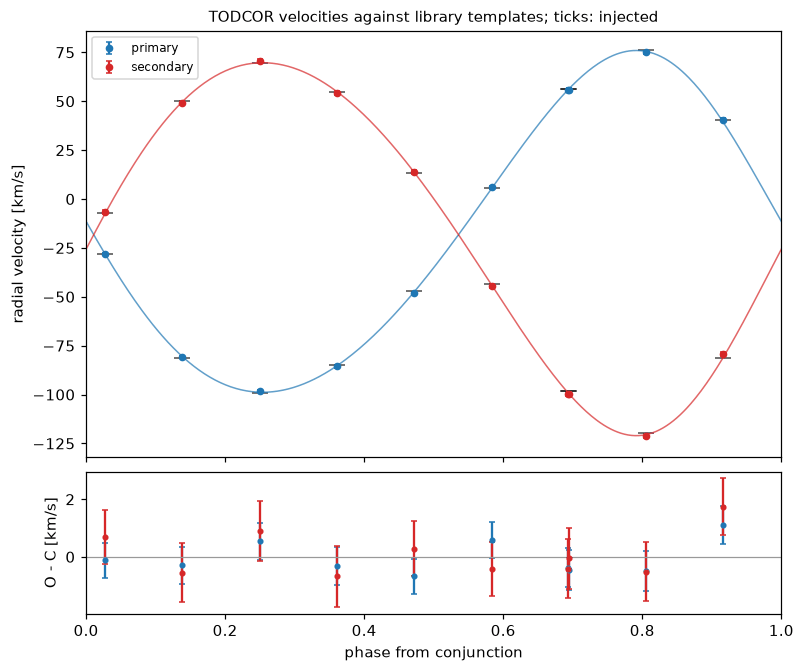

In [5]:
orbit = ab.fit_rv_orbit(table, period=PERIOD)
print(orbit.summary())
print(
    f"\ninjected: K1 {k1:.2f}, K2 {k2:.2f} km/s, e {ECC}, gamma {GAMMA:+.1f} km/s; "
    f"errors: K1 {orbit.k[0] - k1:+.2f}, K2 {orbit.k[1] - k2:+.2f}, "
    f"gamma {orbit.gamma[0] - GAMMA:+.2f} km/s, e {orbit.ecc - ECC:+.3f}"
)
fig, axes = ab.plot_velocity_table(table, orbit=orbit, truth=truth.velocities)
axes[0].set_title("TODCOR velocities against library templates; ticks: injected", fontsize=10)
fig.set_layout_engine("constrained")

### The chi-square surface, at a wide and at a blended epoch

The velocities are the minimum of the chi-square over the two shifts. The figure shows the
surface at the epoch of largest separation and at the most blended one, as contours of the
rise above the minimum. Where the lines are resolved the surface has one minimum. Where
they overlap it is a valley along which the light-weighted mean velocity is constant, with
two minima: the injected pair, and the pair with the same mean and the velocity difference
of the opposite sign. The exchanged pair reproduces the first two moments of the blended
line profile. Only the asymmetry of the profile distinguishes the two. It grows with the
cube of the separation and vanishes for equal light fractions, so noise can make the wrong
minimum the deeper. The table records the rise in chi-square from the minimum returned to
the other one as `margin`, which is given above each panel. Where it is below 9 the table
flags the epoch as `blended` and records the velocities of the other minimum as
`alternative`. Step 3 measures how often the wrong minimum is returned, what the flag
marks, and what an orbit makes of the two minima.

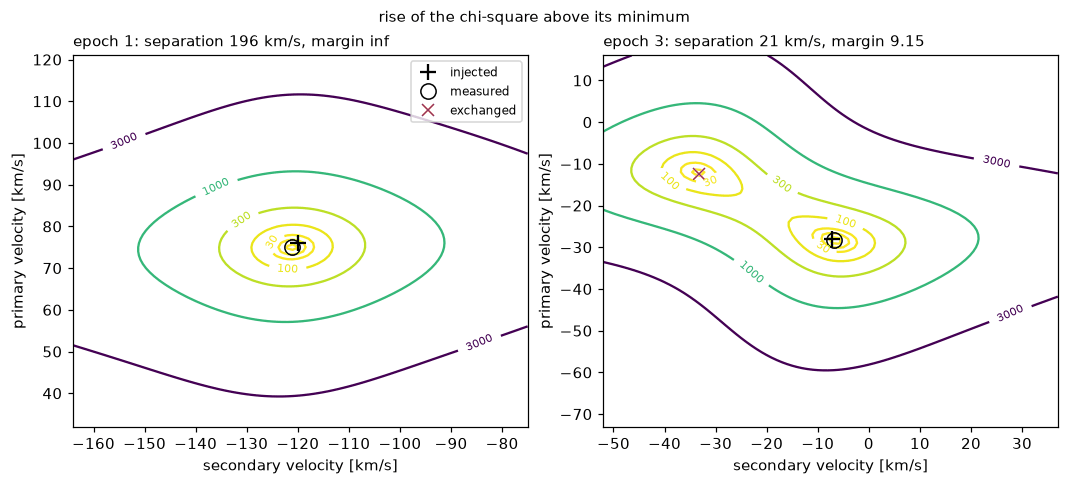

In [6]:
separation = np.abs(truth.velocities[0] - truth.velocities[1])
far, near = int(np.argmax(separation)), int(np.argmin(separation))
# A finer grid for the figure only, so that the contours resolve the valley.
figure_grid = ab.LogGrid.covering(dataset, 1.0, v_margin_kms=V_SEARCH, lsf_sigma_kms=delivered)
figure_templates = library_templates((PRIMARY, SECONDARY), VSINI, grid=figure_grid)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.3))
for ax, j in zip(axes, (far, near), strict=True):
    v1, v2 = truth.velocities[:, j]
    surface = ab.todcor_surface(
        dataset,
        j,
        figure_templates,
        v_range=[(v1 - 45.0, v1 + 45.0), (v2 - 45.0, v2 + 45.0)],
        light=LIGHT,
        lsf_sigma_v={"RVS": delivered},
    )
    rise = surface.chi2 - surface.chi2.min()
    levels = [2.3, 11.8, 30.0, 100.0, 300.0, 1000.0, 3000.0]
    contours = ax.contour(surface.v2, surface.v1, rise, levels=levels, cmap="viridis_r")
    ax.clabel(contours, fmt="%g", fontsize=7)
    ax.plot(v2, v1, "k+", ms=11, mew=1.5, label="injected")
    ax.plot(*table.velocity[::-1, j], "o", mfc="none", mec="k", ms=10, label="measured")
    mean, diff = LIGHT[0] * v1 + LIGHT[1] * v2, v1 - v2
    # The pair with the same light-weighted mean and the opposite difference.
    ax.plot(
        mean + LIGHT[0] * diff, mean - LIGHT[1] * diff, "x", color="C3", ms=8, label="exchanged"
    )
    ax.set_xlim(surface.v2[0], surface.v2[-1])
    ax.set_ylim(surface.v1[0], surface.v1[-1])
    ax.set_xlabel("secondary velocity [km/s]")
    ax.set_ylabel("primary velocity [km/s]")
    ax.set_title(
        f"epoch {j}: separation {separation[j]:.0f} km/s, margin {table.margin[j]:.3g}",
        fontsize=10,
        loc="left",
    )
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("rise of the chi-square above its minimum", fontsize=10)
fig.set_layout_engine("constrained")

## Step 3: the errors against the line separation and the S/N

The ten epochs of an orbit do not sample the separations evenly. The next cell places the
same two stars at fixed separations from 0 to 160 km/s, forty epochs at each with a random
sign and a random mean velocity, and repeats the measurement at a S/N of 15, 40 and 100 per
detector pixel. An epoch is counted as wrong where either velocity is more than five
quoted errors and 3 km/s from the injected value. The third panel shows the wrong epochs,
the epochs the table flags as blended, and the wrong epochs it does not flag.

[18 s for 1440 epochs, simulation included]


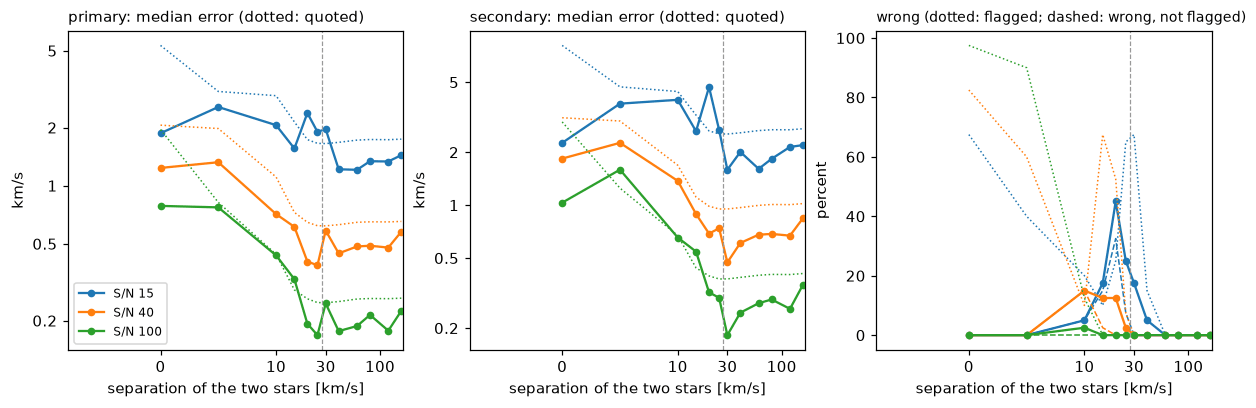

In [7]:
SEPARATIONS = np.array([0, 5, 10, 15, 20, 25, 30, 40, 60, 80, 120, 160], dtype=float)
PER_SEPARATION = 40


def separation_sweep(snr, seed=7):
    """Epochs of the reference pair at fixed separations, and their velocity table."""
    rng = np.random.default_rng(seed)
    n = SEPARATIONS.size * PER_SEPARATION
    sep = np.repeat(SEPARATIONS, PER_SEPARATION) * rng.choice([-1.0, 1.0], n)
    mean = rng.uniform(-40.0, 40.0, n)
    velocities = np.stack([mean - LIGHT[1] * sep, mean + LIGHT[0] * sep])
    epochs, injected = simulate_rvs_dataset(
        components,
        grid,
        bjd=2457000.0 + np.arange(n),
        light_fractions=LIGHT,
        velocities=velocities,
        snr=snr,
        product=RVS_DR4_EPOCH,
        library=library,
        seed=seed,
    )
    measured = ab.todcor(epochs, templates, v_range=(-V_SEARCH, V_SEARCH), light=LIGHT, **RVS)
    return np.abs(sep), injected.velocities, measured, epochs


def wrong(table, v_true):
    """Epochs with either velocity more than five quoted errors and 3 km/s off."""
    error = np.abs(table.velocity - v_true)
    return np.any((error > 5.0 * table.sigma) & (error > 3.0), axis=0)


t0 = time.perf_counter()
sweeps = {snr: separation_sweep(snr) for snr in (15.0, 40.0, 100.0)}
n_epochs = sum(s[2].n_epochs for s in sweeps.values())
print(f"[{time.perf_counter() - t0:.0f} s for {n_epochs} epochs, simulation included]")

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
for colour, (snr, (sep, v_true, tab, _)) in zip(("C0", "C1", "C2"), sweeps.items(), strict=True):
    miss = wrong(tab, v_true)
    error = np.abs(tab.velocity - v_true)
    at = [sep == s for s in SEPARATIONS]
    for ax, row, name in zip(axes[:2], (0, 1), ("primary", "secondary"), strict=True):
        ax.plot(
            SEPARATIONS,
            [np.nanmedian(error[row, m]) for m in at],
            "o-",
            ms=4,
            color=colour,
            label=f"S/N {snr:.0f}",
        )
        ax.plot(
            SEPARATIONS, [np.nanmedian(tab.sigma[row, m]) for m in at], ":", color=colour, lw=1.0
        )
        ax.set_title(f"{name}: median error (dotted: quoted)", fontsize=10, loc="left")
        ax.set_ylabel("km/s")
    axes[2].plot(SEPARATIONS, [100 * np.mean(miss[m]) for m in at], "o-", ms=4, color=colour)
    axes[2].plot(
        SEPARATIONS, [100 * np.mean(tab.blended[m]) for m in at], ":", color=colour, lw=1.0
    )
    axes[2].plot(
        SEPARATIONS, [100 * np.mean((miss & tab.good)[m]) for m in at], "--", color=colour, lw=1.0
    )
axes[2].set_title("wrong (dotted: flagged; dashed: wrong, not flagged)", fontsize=9, loc="left")
axes[2].set_ylabel("percent")
for ax in axes:
    ax.axvline(2.3548 * delivered, color="0.6", lw=0.8, ls="--")
    ax.set_xscale("symlog", linthresh=10.0)
    ax.set_xticks([0, 10, 30, 100])
    ax.set_xticklabels(["0", "10", "30", "100"])
    ax.set_xlabel("separation of the two stars [km/s]")
for ax in axes[:2]:
    ax.set_yscale("log")
    ax.set_yticks([0.2, 0.5, 1.0, 2.0, 5.0])
    ax.set_yticklabels(["0.2", "0.5", "1", "2", "5"])
    ax.minorticks_off()
axes[0].legend(fontsize=8)
fig.set_layout_engine("constrained")

The dashed line is the FWHM of the line-spread function. The next cell tabulates the
errors at a S/N of 40 and, at each S/N, the number of wrong epochs, with the number of
them that are not flagged in brackets, and the number of flagged epochs. It then counts
what the second minimum flags, and gives the errors of the resolved epochs. It also repeats
the S/N 40 measurement without the noise correlation, which changes the quoted errors and
leaves the velocities as they are.

In [8]:
lines = [
    "| separation [km/s] | median error at S/N 40, primary and secondary [km/s] "
    "| wrong at S/N 15 | at S/N 40 | at S/N 100 | flagged at S/N 15 | at S/N 40 | at S/N 100 |",
    "|---|---|---|---|---|---|---|---|",
]
sep, v_true, tab, epochs_40 = sweeps[40.0]
error = np.abs(tab.velocity - v_true)
for s in SEPARATIONS:
    m = sep == s
    wrong_cells, flagged_cells = [], []
    for _, injected_v, measured, _ in sweeps.values():
        miss = wrong(measured, injected_v)
        wrong_cells.append(f"{int(miss[m].sum())} ({int((miss & measured.good)[m].sum())})")
        flagged_cells.append(f"{int(measured.blended[m].sum())}")
    lines.append(
        f"| {s:.0f} | {np.nanmedian(error[0, m]):.2f}, {np.nanmedian(error[1, m]):.2f} "
        f"| {' | '.join(wrong_cells)} | {' | '.join(flagged_cells)} |"
    )
display(Markdown("\n".join(lines)))
print(f"each row has {PER_SEPARATION} epochs; in brackets, the wrong epochs not flagged\n")


def wrong_in_either_order(table, v_true):
    """Epochs that are wrong as labelled and with the two velocities interchanged."""
    error = np.abs(table.velocity[::-1] - v_true)
    interchanged = np.any((error > 5.0 * table.sigma[::-1]) & (error > 3.0), axis=0)
    return wrong(table, v_true) & interchanged


def other_minimum(table):
    """The table with the other minimum taken at every epoch that records one."""
    stored = np.all(np.isfinite(table.alternative), axis=0)
    return Assignment(np.zeros_like(stored), stored, stored).apply(table)


for snr, (_, v_true, tab, _) in sweeps.items():
    miss, second, either = (
        wrong(tab, v_true),
        tab.second_minimum,
        wrong_in_either_order(tab, v_true),
    )
    kept = miss & tab.good
    print(
        f"S/N {snr:.0f}: {int(miss.sum())} wrong; a second minimum flags "
        f"{int((miss & second).sum())} of them and {int((second & ~miss).sum())} correct epochs; "
        f"of the {int(kept.sum())} not flagged, {int((kept & ~either).sum())} are right with the "
        "two velocities interchanged"
    )
    other_wrong = wrong(other_minimum(tab), v_true)
    print(
        f"  the other minimum is right at {int((miss & second & ~other_wrong).sum())} of the wrong "
        f"epochs flagged, and wrong at {int((second & ~miss & other_wrong).sum())} of the correct "
        "ones"
    )
print()

for snr, (sep, v_true, tab, _) in sweeps.items():
    print(f"S/N {snr:.0f}, separations of 60 km/s and above:")
    report(tab, v_true, select=sep >= 60.0)

sep, v_true, tab, epochs_40 = sweeps[40.0]
white = ab.todcor(
    epochs_40, templates, v_range=(-V_SEARCH, V_SEARCH), light=LIGHT, lsf_sigma_v=RVS["lsf_sigma_v"]
)
print("S/N 40, the same epochs with the noise taken as white:")
report(white, v_true, select=sep >= 60.0)

| separation [km/s] | median error at S/N 40, primary and secondary [km/s] | wrong at S/N 15 | at S/N 40 | at S/N 100 | flagged at S/N 15 | at S/N 40 | at S/N 100 |
|---|---|---|---|---|---|---|---|
| 0 | 1.24, 1.84 | 0 (0) | 0 (0) | 0 (0) | 27 | 33 | 39 |
| 5 | 1.32, 2.26 | 0 (0) | 0 (0) | 0 (0) | 16 | 24 | 36 |
| 10 | 0.71, 1.37 | 2 (2) | 6 (6) | 1 (0) | 8 | 4 | 5 |
| 15 | 0.61, 0.89 | 7 (6) | 5 (1) | 0 (0) | 4 | 27 | 0 |
| 20 | 0.40, 0.69 | 18 (13) | 5 (0) | 0 (0) | 10 | 21 | 0 |
| 25 | 0.39, 0.74 | 10 (3) | 1 (0) | 0 (0) | 26 | 3 | 0 |
| 30 | 0.59, 0.47 | 7 (0) | 0 (0) | 0 (0) | 27 | 0 | 0 |
| 40 | 0.45, 0.61 | 2 (0) | 0 (0) | 0 (0) | 6 | 0 | 0 |
| 60 | 0.48, 0.68 | 0 (0) | 0 (0) | 0 (0) | 0 | 0 | 0 |
| 80 | 0.49, 0.69 | 0 (0) | 0 (0) | 0 (0) | 0 | 0 | 0 |
| 120 | 0.48, 0.67 | 0 (0) | 0 (0) | 0 (0) | 0 | 0 | 0 |
| 160 | 0.58, 0.84 | 0 (0) | 0 (0) | 0 (0) | 0 | 0 | 0 |

each row has 40 epochs; in brackets, the wrong epochs not flagged

S/N 15: 46 wrong; a second minimum flags 22 of them and 48 correct epochs; of the 24 not flagged, 24 are right with the two velocities interchanged
  the other minimum is right at 22 of the wrong epochs flagged, and wrong at 48 of the correct ones
S/N 40: 17 wrong; a second minimum flags 10 of them and 43 correct epochs; of the 7 not flagged, 6 are right with the two velocities interchanged
  the other minimum is right at 10 of the wrong epochs flagged, and wrong at 43 of the correct ones
S/N 100: 1 wrong; a second minimum flags 1 of them and 5 correct epochs; of the 0 not flagged, 0 are right with the two velocities interchanged
  the other minimum is right at 1 of the wrong epochs flagged, and wrong at 4 of the correct ones

S/N 15, separations of 60 km/s and above:
  primary   rms error 1.74 km/s, median quoted error 1.73 km/s, pull rms 1.00
  secondary rms error 3.06 km/s, median quoted error 2.69 km/s, pull rms 1.1

S/N 40, the same epochs with the noise taken as white:
  primary   rms error 0.65 km/s, median quoted error 0.52 km/s, pull rms 1.23
  secondary rms error 1.11 km/s, median quoted error 0.82 km/s, pull rms 1.36


Three ranges of separation behave differently.

- **At 60 km/s and above**, 2.2 FWHM, the errors are those of the photon noise. The rms
  error of the primary, which has 62 percent of the light, is 1.74, 0.65 and 0.26 km/s at a
  S/N of 15, 40 and 100, which is 26 km/s divided by the S/N. The secondary's is 1.7 times
  larger. The pull rms is 1.0 for the primary and 1.1 for the secondary. With the noise
  taken as white the quoted errors are a fifth smaller and the pull rms is 1.2 to 1.4. No
  epoch is wrong, and none is flagged.
- **Below 10 km/s** the two velocities are not measured separately. At a S/N of 40 the
  table flags 57 of these 80 epochs as blended, by the curvature of the surface at its
  minimum, and the quoted errors are as large as the errors.
- **From 10 km/s to about 1.5 FWHM** the surface is the valley of step 2 with its two
  minima, and the noise decides which is the lower. The wrong epochs are those at which the
  exchanged pair is returned: 46 of 480 at a S/N of 15, at separations up to 40 km/s, 17 at
  a S/N of 40, up to 25 km/s, and one at a S/N of 100. The curvature at the exchanged pair
  is regular, so the quoted errors are those of a resolved epoch. At every one of these
  epochs the injected pair is the other minimum, at most 8.4 above in chi-square
  (`scripts/todcor_blend_bench.py`). A margin below 9 flags 22 of the 46, 10 of the 17 and
  the one, with 48, 43 and 5 epochs that were measured correctly. At each of the 33 flagged
  wrong epochs the minimum that the table records as `alternative` is the injected pair,
  and at 95 of the 96 flagged correct ones it is a wrong pair.

The flag counts a second minimum only where it gives a different pair of velocities: in
either order of the two stars, some velocity differs by more than three quoted errors. At
the 24 and 7 wrong epochs that are not flagged, the two minima are the same pair in the two
orders to within that tolerance. With the two velocities interchanged, all but one of the
31 are within five quoted errors or 3 km/s of the injected values. Step 5 gives the reason
for the rule and makes the interchange with the orbit.

The search does not cause the wrong epochs. On every epoch of this sweep with the lines at
most 60 km/s apart, `todcor` returns the lowest chi-square of a lattice of an eighth of a
pixel.

### The orbit and the two minima

One epoch does not decide between the two minima of a blended surface, and an orbit does.
`albireo.rvorbit.assign_components` fits a Keplerian at a known period to the usable
epochs. At every epoch flagged for a second minimum it compares the two recorded pairs
with the orbit, each with the covariance of its own velocities, adds to the other minimum
its rise in the chi-square of the spectrum, and takes the pair with the lower sum. The fit
is then repeated with those epochs, until nothing changes. The next cell observes the
reference pair at 240 epochs over ten orbits, at a S/N of 15 and of 40, and counts the
wrong epochs before and after.

In [9]:
N_DECIDED = 240
decided_bjd = 2457000.013 + np.sort(np.random.default_rng(5).uniform(0.0, 10 * PERIOD, N_DECIDED))
for snr in (15.0, 40.0):
    epochs, injected = simulate_rvs_dataset(
        components,
        grid,
        bjd=decided_bjd,
        light_fractions=LIGHT,
        orbit=orbit_true,
        snr=snr,
        product=RVS_DR4_EPOCH,
        library=library,
        seed=11,
    )
    v_true = np.asarray(injected.velocities)
    measured = ab.todcor(epochs, templates, v_range=(-V_SEARCH, V_SEARCH), light=LIGHT, **RVS)
    left_out = ab.fit_rv_orbit(measured, period=PERIOD)
    assigned, fitted, decided = assign_components(measured, period=PERIOD)
    before, after = wrong(measured, v_true), wrong(assigned, v_true)
    pull = ((assigned.velocity - v_true) / assigned.sigma)[:, decided.resolved]
    pull_rms = np.sqrt(np.mean(pull**2, axis=1))
    print(
        f"S/N {snr:.0f}: {int(measured.second_minimum.sum())} of {N_DECIDED} epochs flagged by a "
        f"second minimum; {int(decided.resolved.sum())} decided by the orbit, the other minimum "
        f"taken at {int(decided.alternative.sum())}"
    )
    print(
        f"  wrong epochs as measured: {int(before.sum())}, of which "
        f"{int((before & measured.second_minimum).sum())} flagged by a second minimum and "
        f"{int((before & measured.good).sum())} usable; wrong among the usable epochs after the "
        f"decisions: {int((after & assigned.good).sum())}"
    )
    print(
        f"  usable epochs {int(measured.good.sum())} -> {int(assigned.good.sum())}; pull rms of "
        f"the decided epochs {pull_rms[0]:.2f} and {pull_rms[1]:.2f}"
    )
    for label, solution in (("flagged epochs left out", left_out), ("decided", fitted)):
        print(
            f"  {label:24s} K {solution.k[0]:.2f} +- {solution.errors['k'][0]:.2f} and "
            f"{solution.k[1]:.2f} +- {solution.errors['k'][1]:.2f} km/s (injected {k1:.2f} and "
            f"{k2:.2f})"
        )

S/N 15: 8 of 240 epochs flagged by a second minimum; 8 decided by the orbit, the other minimum taken at 2
  wrong epochs as measured: 6, of which 2 flagged by a second minimum and 4 usable; wrong among the usable epochs after the decisions: 0
  usable epochs 229 -> 237; pull rms of the decided epochs 1.93 and 1.48
  flagged epochs left out  K 87.70 +- 0.26 and 95.05 +- 0.39 km/s (injected 87.70 and 95.00)
  decided                  K 87.78 +- 0.18 and 95.05 +- 0.28 km/s (injected 87.70 and 95.00)


S/N 40: 6 of 240 epochs flagged by a second minimum; 6 decided by the orbit, the other minimum taken at 1
  wrong epochs as measured: 2, of which 1 flagged by a second minimum and 1 usable; wrong among the usable epochs after the decisions: 0
  usable epochs 232 -> 238; pull rms of the decided epochs 1.50 and 0.74
  flagged epochs left out  K 87.71 +- 0.07 and 95.03 +- 0.10 km/s (injected 87.70 and 95.00)
  decided                  K 87.72 +- 0.06 and 95.03 +- 0.10 km/s (injected 87.70 and 95.00)


At a S/N of 15 the table flags 8 of the 240 epochs for a second minimum. The orbit decides
all of them and takes the other minimum at 2. Six epochs are wrong as measured: those 2,
and 4 that are not flagged, at which the two minima are the same pair in the two orders
and the orbit interchanges the two velocities (step 5). No usable epoch is wrong
afterwards, and the usable epochs rise from 229 to 237. At a S/N of 40 the orbit decides 6
flagged epochs and takes the other minimum at 1, 2 epochs are wrong as measured and none
afterwards. The errors of the semi-amplitudes fall from 0.26 and 0.39 km/s to 0.18 and
0.28 km/s at a S/N of 15, where four wrong epochs no longer enter the fit as measured.

The decided epochs are blended, and their quoted errors are those of the curvature at one
of two minima of a valley. They are smaller than the errors: the pull rms of the 8 and 6
decided epochs is 1.9 and 1.5 at a S/N of 15, and 1.5 and 0.7 at 40.

## Step 4: templates that differ from the stars

The stars of a real binary are not known in advance, and the templates are chosen from a
classification. The next cell observes the same pair at 80 epochs spread over one orbit and
measures it against templates whose labels are offset from the injected ones, one label at
a time. The light fractions are measured (`light="global"`), as they would be for a real
star. The statistics are over the epochs with the lines more than 60 km/s apart, so that
they describe the templates and not the blends of step 3. A template pair can also be
matched to the stars in the other order. The comparison is made in the order that fits, and
the last column records it. The usable epochs are those the table does not flag as blended
or as at the edge of the search.

In [10]:
N_ORBIT = 80
orbit_epochs, orbit_truth = simulate_rvs_dataset(
    components,
    grid,
    bjd=2457000.013 + np.linspace(0.0, PERIOD, N_ORBIT, endpoint=False),
    light_fractions=LIGHT,
    orbit=orbit_true,
    snr=SNR,
    product=RVS_DR4_EPOCH,
    library=library,
    seed=3,
)
resolved = np.abs(orbit_truth.velocities[0] - orbit_truth.velocities[1]) > 60.0


def offset(star, **change):
    """The labels of a star with some of them offset, kept inside the library."""
    out = dict(star)
    for axis, delta in change.items():
        out[axis] = float(np.clip(out[axis] + delta, *library.bounds[axis]))
    return out


def both(**change):
    return offset(PRIMARY, **change), offset(SECONDARY, **change)


lo, hi = library.bounds["teff"]
MIDDLE = {axis: float(np.mean(library.bounds[axis])) for axis in ("logg", "mh")}
GENERIC = [{"teff": lo + (hi - lo) * 2 / 3, **MIDDLE}, {"teff": lo + (hi - lo) / 3, **MIDDLE}]

CASES = {
    "the injected labels": ((PRIMARY, SECONDARY), VSINI),
    "both 250 K cooler": (both(teff=-250.0), VSINI),
    "both 250 K hotter": (both(teff=250.0), VSINI),
    "both 500 K hotter": (both(teff=500.0), VSINI),
    "one temperature for both, 5900 K": (
        (offset(PRIMARY, teff=-200.0), offset(SECONDARY, teff=200.0)),
        VSINI,
    ),
    "log g higher by 0.5 dex": (both(logg=0.5), VSINI),
    "[M/H] lower by 0.3 dex": (both(mh=-0.3), VSINI),
    "[M/H] higher by 0.3 dex": (both(mh=0.3), VSINI),
    "no rotation": ((PRIMARY, SECONDARY), (0.0, 0.0)),
    "v sin i of 30 km/s": ((PRIMARY, SECONDARY), (30.0, 30.0)),
    "v sin i of 50 km/s": ((PRIMARY, SECONDARY), (50.0, 50.0)),
    "generic: 6000 and 5000 K, no rotation": (GENERIC, (0.0, 0.0)),
}


def better_order(table, v_true, select=None):
    """The order of the table's components that is closer to the injected velocities."""
    use = table.good if select is None else table.good & select
    if not use.any():
        return [0, 1]
    direct = np.mean((table.velocity[:, use] - v_true[:, use]) ** 2)
    other = np.mean((table.velocity[::-1, use] - v_true[:, use]) ** 2)
    return [1, 0] if other < direct else [0, 1]


t0 = time.perf_counter()
lines = [
    "| templates | usable epochs | zero point, A and B [km/s] | scatter, A and B [km/s] "
    "| pull rms, A and B | light fraction of A | order |",
    "|---|---|---|---|---|---|---|",
]
for label, (labels, vsini) in CASES.items():
    tab = ab.todcor(
        orbit_epochs,
        library_templates(labels, vsini),
        v_range=(-V_SEARCH, V_SEARCH),
        light="global",
        **RVS,
    )
    order = better_order(tab, orbit_truth.velocities, resolved)
    use = tab.good & resolved
    error = (tab.velocity[order] - orbit_truth.velocities)[:, use]
    pull = error / tab.sigma[order][:, use]
    lines.append(
        f"| {label} | {int(tab.good.sum())} of {N_ORBIT} "
        f"| {error[0].mean():+.2f}, {error[1].mean():+.2f} "
        f"| {error[0].std():.2f}, {error[1].std():.2f} "
        f"| {np.sqrt(np.mean(pull[0] ** 2)):.2f}, {np.sqrt(np.mean(pull[1] ** 2)):.2f} "
        f"| {np.nanmedian(tab.light[order[0]]):.3f} "
        f"| {'exchanged' if order[0] else 'as declared'} |"
    )
print(
    f"[{time.perf_counter() - t0:.0f} s for {len(CASES)} template pairs on {N_ORBIT} epochs, "
    f"{int(resolved.sum())} of them resolved; the injected light fraction of A is {LIGHT[0]:.3f}]"
)
Markdown("\n".join(lines))

[29 s for 12 template pairs on 80 epochs, 62 of them resolved; the injected light fraction of A is 0.625]


| templates | usable epochs | zero point, A and B [km/s] | scatter, A and B [km/s] | pull rms, A and B | light fraction of A | order |
|---|---|---|---|---|---|---|
| the injected labels | 74 of 80 | -0.10, -0.13 | 0.63, 0.92 | 0.97, 0.93 | 0.623 | as declared |
| both 250 K cooler | 74 of 80 | +0.04, +0.05 | 0.62, 1.08 | 0.98, 1.12 | 0.626 | as declared |
| both 250 K hotter | 77 of 80 | -0.33, -0.41 | 0.64, 1.24 | 1.03, 1.20 | 0.622 | as declared |
| both 500 K hotter | 76 of 80 | -0.27, -0.97 | 0.83, 1.36 | 1.17, 1.37 | 0.596 | exchanged |
| one temperature for both, 5900 K | 74 of 80 | -0.00, -0.16 | 0.63, 0.98 | 0.97, 0.97 | 0.612 | as declared |
| log g higher by 0.5 dex | 74 of 80 | +0.06, +0.03 | 0.63, 0.96 | 0.96, 0.94 | 0.627 | as declared |
| [M/H] lower by 0.3 dex | 77 of 80 | -0.34, -0.48 | 0.70, 1.91 | 0.99, 1.62 | 0.617 | as declared |
| [M/H] higher by 0.3 dex | 75 of 80 | +0.04, +0.05 | 0.75, 1.81 | 1.13, 1.78 | 0.628 | as declared |
| no rotation | 76 of 80 | -0.13, -0.10 | 0.62, 0.92 | 1.05, 1.01 | 0.621 | as declared |
| v sin i of 30 km/s | 72 of 80 | -0.01, -0.10 | 0.75, 1.16 | 0.81, 0.77 | 0.628 | as declared |
| v sin i of 50 km/s | 67 of 80 | -0.10, +0.11 | 1.08, 2.17 | 0.78, 0.94 | 0.635 | as declared |
| generic: 6000 and 5000 K, no rotation | 78 of 80 | -0.25, -0.04 | 0.65, 0.90 | 1.14, 1.01 | 0.642 | as declared |

For this pair the offsets have the following effects.

- **Temperature, gravity and metallicity.** An offset of 250 K, of 0.5 dex in log g or of
  0.3 dex in [M/H] moves the zero point of either star by 0.5 km/s or less, and changes the
  scatter of the primary by less than 20 percent. The scatter of the secondary grows from
  0.92 km/s to between 0.96 and 1.24 km/s under the temperature and gravity offsets and to
  1.8 to 1.9 km/s under the metallicity offsets. The quoted errors do not follow, and the
  pull rms of the secondary reaches 1.8.
- **One temperature.** A single 5900 K spectrum used for both stars gives the velocities of
  the injected pair to within the noise.
- **Rotation.** Templates without rotation give the same velocities, because a v sin i of
  12 km/s is not resolved at a line-spread sigma of 11.7 km/s. Templates rotating at 30 and
  50 km/s leave 72 and 67 usable epochs, where the injected ones leave 74, and widen the
  scatter by up to a factor 2.4.
- **Order.** With both templates 500 K too hot, the cooler one, at 6200 K, fits the 6100 K
  primary better than the hotter one does, and the pair is matched to the stars in the
  other order at every epoch. The table then has the velocities of the two stars under
  each other's names, and no single table shows it.
- **Light fractions.** The measured fraction of the primary is within 0.03 of the injected
  0.625 in every case.

## Step 5: the systems of the recorded disentangling runs

The recorded full runs of the disentangling benchmark analyse 33 simulated systems: 19
drawn from the field distributions and 14 double-lined orbits of the Gaia DR3 catalogue.
Their populations and simulation seeds are in the repository, so the next cell simulates
the same systems with the same seeds and obtains the same epochs. The S/N per pixel and
epoch is 9 to 98, and a system has 10 to 100 epochs.

In [11]:
RUNS = Path("internal/research/2026-09-09-gaia-rvs-benchmark")
population = []
for run in ("field_d63", "gaia_d63"):
    recorded = json.loads((RUNS / run / "manifest.json").read_text(encoding="utf-8"))["simulation"]
    for system in read_population(RUNS / run / "population.json"):
        if system.name in recorded:  # one drawn system has four transits and was not run
            population.append((system, recorded[system.name]))

t0 = time.perf_counter()
simulated = {}
for system, record in population:
    epochs, injected, sim_grid, _ = simulate_system(system, library=library, seed=record["seed"])
    assert epochs.n_epochs == record["n_epochs"] and sim_grid.dv_kms == grid.dv_kms
    assert np.isclose(np.median(injected.snr), record["snr_epoch"])
    simulated[system.name] = (epochs, injected)
n_total = sum(epochs.n_epochs for epochs, _ in simulated.values())
print(
    f"{len(population)} systems, {n_total} epochs, simulated in {time.perf_counter() - t0:.0f} s; "
    "the epoch counts and the S/N are those of the recorded runs"
)

33 systems, 1074 epochs, simulated in 43 s; the epoch counts and the S/N are those of the recorded runs


### What is declared about the templates

A correlation takes no orbit. What it is given is the templates and, optionally, the light
fractions. Each system is measured under five declarations:

| tier | templates | light fractions |
|---|---|---|
| `injected` | the injected labels and rotation | held at the injected values |
| `labels` | the injected labels and rotation | measured |
| `classified` | the labels and rotation of a classification | measured |
| `classified, free scale` | the same templates | measured, with one scale fitted per epoch |
| `generic` | 6000 and 5000 K, no rotation | measured |

The `injected` tier is the upper bound and measures the estimator alone. The `classified`
tier gives every label the error of a classification, drawn once per system: 150 K in
temperature, 0.2 dex in log g, 0.15 dex in [M/H] and 20 percent in v sin i. The free scale
of the fourth tier is `scale="free"`, the original form of TODCOR, in which the depth of
the composite lines is fitted at every epoch and not fixed by the templates. The `generic`
templates are those the pipeline uses to start an analysis that declares no labels, at the
middle of the library box in log g and [M/H]. The velocity range searched is 350 km/s on
either side, as in the disentangling benchmark.

In [12]:
POPULATION_SEARCH = 350.0
population_grid = ab.LogGrid.covering(
    epochs, delivered / 3.0, v_margin_kms=POPULATION_SEARCH + 60.0, lsf_sigma_kms=delivered
)


def classified(system):
    """The labels and rotation of a system with the errors of a classification."""
    rng = np.random.default_rng(zlib.crc32(system.name.encode()))
    metallicity_error = rng.normal(0.0, 0.15)
    labels = []
    for star in system.labels:
        drawn = {
            "teff": star["teff"] + rng.normal(0.0, 150.0),
            "logg": star["logg"] + rng.normal(0.0, 0.2),
            "mh": star["mh"] + metallicity_error,
        }
        labels.append({k: float(np.clip(v, *library.bounds[k])) for k, v in drawn.items()})
    vsini = [float(v * np.exp(rng.normal(0.0, 0.2))) for v in (system.vsini1, system.vsini2)]
    return labels, vsini


def declare(system, tier):
    """The labels, the rotation and the `todcor` options of a system under a tier."""
    known = (list(system.labels), [system.vsini1, system.vsini2])
    if tier == "injected":
        return *known, {"light": system.light_fractions}
    if tier == "labels":
        return *known, {"light": "global"}
    if tier == "classified":
        return *classified(system), {"light": "global"}
    if tier == "classified, free scale":
        return *classified(system), {"light": "global", "scale": "free"}
    return GENERIC, [0.0, 0.0], {"light": "global"}


TIERS = ("injected", "labels", "classified", "classified, free scale", "generic")

### Which velocity belongs to which star

Two alike spectra at alike light fractions give a surface that is nearly symmetric under
the exchange of the two shifts. The minimum with the two velocities interchanged then
exists at every separation, about as deep as the solution, and each epoch returns the pair
in one of the two orders. Of these 33 systems, 25 have a mass ratio above 0.9. The pair of
velocities at such an epoch is measured, and its assignment to the two stars is not. The
blend flag therefore does not count the minimum of the other order, which would mark most
epochs of such a pair (`docs/benchmarks.md`).

The orbit assigns the pair. With the period known, as a Gaia orbit or a light curve gives
it, `albireo.rvorbit.assign_components` fits the Keplerian and exchanges the epochs that it
contradicts, repeating until none is left. In the same rounds it decides the epochs with
a second minimum, as in step 3. It does so from the table as measured and from up to three
further assignments made from the period alone: the magnitude of the velocity
difference, which does not depend on the assignment, is fitted with the magnitude of a
Keplerian's relative velocity over a grid of phase, eccentricity and argument of
periastron, and the sign of each of the best curves assigns the epochs. The assignment
reached from the table as measured is kept unless the best of the others lowers the
chi-square of the orbit by more than nine times its reduced chi-square. No epoch is
exchanged where the light fractions differ by more than a factor of three, the rule of the
pipeline.

The next cell applies it to the pair of the population whose flux ratio is closest to one,
measured against the injected templates. Which of two alike stars is called the first is
not determined by the table. For this reason the injected values are used in one place,
after the measurement: a template pair can be matched to the two stars in the other order
as a whole, and every comparison below is made in the order that fits.

In [13]:
no_light = []  # (tier, system) where no epoch gave positive amplitudes to both templates


def measure(system, tier):
    """The velocity table of a system under a tier, and the seconds the correlation took.

    `light="global"` raises an error where no epoch gives a positive amplitude to both
    templates, since there is then no light fraction to hold. Such a system is listed in
    `no_light` and measured with the amplitudes of each epoch, so that it stays in the
    counts.
    """
    epochs, injected = simulated[system.name]
    labels, vsini, options = declare(system, tier)
    pair = library_templates(labels, vsini, names=("A", "B"), grid=population_grid)
    common = {
        "v_range": (-POPULATION_SEARCH, POPULATION_SEARCH),
        "lsf_sigma_v": RVS["lsf_sigma_v"],
        "noise_correlation": {"RVS": float(np.mean(injected.delivery.lag1))},
    }
    t0 = time.perf_counter()
    try:
        table = ab.todcor(epochs, pair, **common, **options)
    except ValueError:
        if options["light"] != "global":
            raise
        no_light.append((tier, system.name))
        table = ab.todcor(epochs, pair, **common, **{**options, "light": "free"})
    return table, time.perf_counter() - t0


twin = min((system for system, _ in population), key=lambda system: abs(system.light_ratio - 1.0))
measured, _ = measure(twin, "injected")
as_measured = ab.fit_rv_orbit(measured, period=twin.period)
assigned, fitted, decided = assign_components(measured, period=twin.period)
print(
    f"{twin.name}: F2/F1 {twin.light_ratio:.2f}, P {twin.period:.2f} d, injected K "
    f"{twin.k1:.1f} and {twin.k2:.1f} km/s; {int(decided.exchanged.sum())} of "
    f"{measured.n_epochs} epochs exchanged by the orbit"
)
for label, orbit in (("as measured", as_measured), ("assigned", fitted)):
    print(
        f"  {label:12s} chi-square {orbit.chi2:9.1f}, K {orbit.k[0]:6.1f} and {orbit.k[1]:6.1f} "
        f"km/s, e {orbit.ecc:.2f}"
    )

gaia-37608387208382848: F2/F1 0.98, P 6.10 d, injected K 68.5 and 68.7 km/s; 5 of 15 epochs exchanged by the orbit
  as measured  chi-square   12611.4, K   40.8 and   39.8 km/s, e 0.55
  assigned     chi-square      19.0, K   68.6 and   68.7 km/s, e 0.02


### The run

For the pair above, the orbit fitted to the table as measured has semi-amplitudes of 41 and
40 km/s at a chi-square of 12,611. With 5 of the 15 epochs exchanged it has 68.6 and
68.7 km/s, for an injected 68.5 and 68.7, at a chi-square of 19.

Every system is measured under every tier, its epochs are assigned and its orbit fitted,
and the result is compared with the injected values. An orbit that cannot be fitted leaves
the table as measured. For comparison, the orbit is also fitted after one exchange by the
first fit, with the flagged epochs left out.

Measured light fractions are the median of the amplitudes over the epochs at which both
are positive. Templates that describe neither star can fit a blend as a difference of the
two, with one amplitude negative, and `todcor` raises an error where no epoch has positive
amplitudes. The cell lists such a system and measures it with the amplitudes of each
epoch, so that its epochs stay in the counts.

In [14]:
def one_exchange(table, period):
    """The table and the orbit after one exchange by the first fit, for comparison."""
    fitted = ab.fit_rv_orbit(table, period=period)
    fractions = np.nanmedian(table.light, axis=1)
    if fractions.min() > 0.0 and fractions.max() / fractions.min() > 3.0:
        return table, fitted
    exchanged, moved = reassign_by_orbit(table, fitted.predict(table.bjd))
    return (
        (exchanged, ab.fit_rv_orbit(exchanged, period=period)) if moved.any() else (table, fitted)
    )


def k_errors(table, orbit, system, v_true):
    """The relative errors of K1 and K2, in the order of the table that fits."""
    order = better_order(table, v_true)
    return np.asarray(orbit.k)[order] / np.array([system.k1, system.k2]) - 1.0


def run_tier(tier):
    """Every system under one tier: a row per system and the errors of every epoch."""
    rows, seconds = [], 0.0
    for system, _ in population:
        injected = simulated[system.name][1]
        measured, elapsed = measure(system, tier)
        seconds += elapsed
        v_true = np.asarray(injected.velocities)
        k_error, k_once, k_left_out = (np.full(2, np.nan) for _ in range(3))
        try:
            assigned, fitted, decided = assign_components(measured, period=system.period)
            k_error = k_errors(assigned, fitted, system, v_true)
        except ValueError:  # too few usable velocities for an orbit
            assigned, fitted, decided = measured, None, Assignment.none(measured.n_epochs)
        if fitted is not None:
            k_once = k_errors(*one_exchange(measured, system.period), system, v_true)
        try:
            # Without the recorded second minima the flagged epochs have no weight.
            closed = replace(measured, alternative=np.full(measured.velocity.shape, np.nan))
            table, orbit, _ = assign_components(closed, period=system.period)
            k_left_out = k_errors(table, orbit, system, v_true)
        except ValueError:
            pass
        order = better_order(assigned, v_true)
        error = assigned.velocity[order] - v_true
        sigma = assigned.sigma[order]
        row = {
            "system": system,
            "good": assigned.good,
            "error": error,
            "pull": error / sigma,
            "separation": np.abs(v_true[0] - v_true[1]),
            "snr": np.asarray(injected.snr),
            "exchanged_epochs": int(decided.exchanged.sum()),
            "second_minimum": int(measured.second_minimum.sum()),
            "usable_as_measured": int(measured.good.sum()),
            "decided": decided.resolved,
            "other_minimum": int(decided.alternative.sum()),
            "wrong": np.any((np.abs(error) > 5.0 * sigma) & (np.abs(error) > 3.0), axis=0),
            "other_order": bool(order[0]),
            "light_error": float(
                np.nanmedian(assigned.light[order[0]] / assigned.light.sum(axis=0))
                - system.light_fractions[0]
            ),
            "k_error": k_error,
            "k_once": k_once,
            "k_left_out": k_left_out,
            "gamma_error": np.nan if fitted is None else float(fitted.gamma[0] - system.gamma),
        }
        rows.append(row)
    return rows, seconds


t_start = time.perf_counter()
results, correlation_seconds = {}, {}
for tier in TIERS:
    t0 = time.perf_counter()
    results[tier], correlation_seconds[tier] = run_tier(tier)
    print(
        f"{tier:24s} {time.perf_counter() - t0:5.0f} s, of which {correlation_seconds[tier]:.0f} s "
        "in the correlation"
    )
print(
    f"{len(TIERS)} tiers x {len(population)} systems in "
    f"{(time.perf_counter() - t_start) / 60:.1f} min"
)
for tier, name in no_light:
    system = next(system for system, _ in population if system.name == name)
    print(
        f"no epoch with positive amplitudes under {tier}: {name} ({system.teff1:.0f} and "
        f"{system.teff2:.0f} K, largest separation {system.max_separation_kms:.0f} km/s)"
    )

injected                    36 s, of which 13 s in the correlation


labels                      52 s, of which 43 s in the correlation


classified                  54 s, of which 43 s in the correlation


classified, free scale      56 s, of which 47 s in the correlation


generic                     48 s, of which 38 s in the correlation
5 tiers x 33 systems in 4.1 min
no epoch with positive amplitudes under classified: mixed-0015 (6688 and 4767 K, largest separation 50 km/s)
no epoch with positive amplitudes under classified: gaia-7289006178185856 (6735 and 6679 K, largest separation 315 km/s)
no epoch with positive amplitudes under classified, free scale: mixed-0015 (6688 and 4767 K, largest separation 50 km/s)
no epoch with positive amplitudes under classified, free scale: gaia-7289006178185856 (6735 and 6679 K, largest separation 315 km/s)
no epoch with positive amplitudes under generic: gaia-51574864941234048 (6948 and 6529 K, largest separation 32 km/s)


### The key numbers

The first two rows are fractions of all epochs: those usable as measured, and those a
second minimum flags. The third row counts the flagged epochs that the orbit decided, the
epochs among them at which it took the other minimum, and those that are wrong after the
decision, by the criterion of step 3. The fourth row is the fraction of the other usable
epochs that are wrong by the same criterion. The usable epochs of the fifth row include
the decided ones, and the epoch statistics pool them over the systems: the error is the median
absolute difference from the injected velocity, and the next two rows are the fractions of
the velocities within three and beyond five quoted errors. The semi-amplitudes are those
of the orbit fitted to the table, counted where both are within 5 percent of the injected
values, on either side of a largest separation, (K1 + K2)(1 + e), of 100 km/s. The two
rows after them give the same counts with the flagged epochs left out, and after one
exchange only, also without them. The light fraction error and the systemic velocity error
are medians over the systems. A is the primary and B the secondary.

In [15]:
def pooled(rows, key):
    return np.concatenate([row[key][:, row["good"]] for row in rows], axis=1)


WIDE = np.array([system.max_separation_kms > 100.0 for system, _ in population])


def both_of(values, digits=2, scale=1.0):
    return ", ".join(f"{scale * value:.{digits}f}" for value in values)


def key_numbers(rows, seconds):
    error, pull = np.abs(pooled(rows, "error")), np.abs(pooled(rows, "pull"))
    k_error = np.abs(np.array([row["k_error"] for row in rows]))
    within = np.all(k_error < 0.05, axis=1)
    n_epochs = sum(row["good"].size for row in rows)
    n_good = sum(int(row["good"].sum()) for row in rows)
    n_exchanged = sum(row["exchanged_epochs"] for row in rows)
    n_second = sum(row["second_minimum"] for row in rows)
    n_measured = sum(row["usable_as_measured"] for row in rows)
    n_decided = sum(int(row["decided"].sum()) for row in rows)
    n_taken = sum(row["other_minimum"] for row in rows)
    n_wrong = sum(int(row["wrong"][row["decided"]].sum()) for row in rows)
    others = [row["good"] & ~row["decided"] for row in rows]
    n_others = sum(int(mask.sum()) for mask in others)
    n_others_wrong = sum(int(row["wrong"][m].sum()) for row, m in zip(rows, others, strict=True))
    once = np.all(np.abs(np.array([row["k_once"] for row in rows])) < 0.05, axis=1)
    left = np.all(np.abs(np.array([row["k_left_out"] for row in rows])) < 0.05, axis=1)
    light = np.median(np.abs([row["light_error"] for row in rows]))
    gamma = np.nanmedian(np.abs([row["gamma_error"] for row in rows]))
    return {
        "usable epochs as measured [%]": f"{100 * n_measured / n_epochs:.1f}",
        "flagged by a second minimum [%]": f"{100 * n_second / n_epochs:.1f}",
        "decided by the orbit, other minimum taken, wrong": f"{n_decided}, {n_taken}, {n_wrong}",
        "wrong among the other usable epochs [%]": f"{100 * n_others_wrong / n_others:.1f}",
        "usable epochs [%]": f"{100 * n_good / n_epochs:.1f}",
        "epoch velocity error, A and B [km/s]": both_of(np.median(error, axis=1)),
        "within three quoted errors, A and B [%]": both_of(np.mean(pull < 3, axis=1), 1, 100),
        "beyond five quoted errors, A and B [%]": both_of(np.mean(pull > 5, axis=1), 1, 100),
        "light fraction error of A": f"{light:.3f}",
        "K1 and K2 within 5 %, above 100 km/s": f"{within[WIDE].sum()} of {WIDE.sum()}",
        "K1 and K2 within 5 %, below 100 km/s": f"{within[~WIDE].sum()} of {(~WIDE).sum()}",
        "with the flagged epochs left out, above and below": (
            f"{left[WIDE].sum()} and {left[~WIDE].sum()}"
        ),
        "after one exchange only, above and below": f"{once[WIDE].sum()} and {once[~WIDE].sum()}",
        "K1, K2 error above 100 km/s [%]": both_of(np.nanmedian(k_error[WIDE], axis=0), 2, 100),
        "systemic velocity error [km/s]": f"{gamma:.2f}",
        "epochs exchanged by the orbit [%]": f"{100 * n_exchanged / n_epochs:.1f}",
        "systems matched in the other order": f"{sum(row['other_order'] for row in rows)}",
        "correlation time per epoch [ms]": f"{1e3 * seconds / n_epochs:.0f}",
    }


numbers = {tier: key_numbers(results[tier], correlation_seconds[tier]) for tier in TIERS}
lines = ["| quantity | " + " | ".join(TIERS) + " |", "|---|" + "---|" * len(TIERS)]
for quantity in numbers["injected"]:
    lines.append(f"| {quantity} | " + " | ".join(numbers[tier][quantity] for tier in TIERS) + " |")
display(Markdown("\n".join(lines)))

print("median epoch velocity error, A and B [km/s], by population:")
for tier in TIERS:
    by_population = []
    for field in (True, False):
        rows = [row for row in results[tier] if (row["system"].source == "parametric") == field]
        by_population.append(both_of(np.median(np.abs(pooled(rows, "error")), axis=1)))
    print(f"  {tier:24s} field systems {by_population[0]};  Gaia orbits {by_population[1]}")

print("\nthe wrong epochs among those decided, the two systems with the most:")
for tier in TIERS:
    counts = sorted(
        ((int(row["wrong"][row["decided"]].sum()), row["system"].name) for row in results[tier]),
        reverse=True,
    )
    print(f"  {tier:24s} " + "; ".join(f"{name} {n}" for n, name in counts[:2] if n))

print("\nsystems with a semi-amplitude more than 5 percent off, injected tier:")
for row in results["injected"]:
    if not np.all(np.abs(row["k_error"]) < 0.05):
        system = row["system"]
        print(
            f"  {system.name}: P {system.period:.1f} d, e {system.ecc:.2f}, largest separation "
            f"{system.max_separation_kms:.0f} km/s, F2/F1 {system.light_ratio:.2f}, S/N "
            f"{np.median(row['snr']):.0f}, {row['good'].size} epochs; K1 "
            f"{100 * row['k_error'][0]:+.1f} %, K2 {100 * row['k_error'][1]:+.1f} %"
        )

faint = int(np.argmin([system.light_ratio for system, _ in population]))
system = population[faint][0]
print(
    f"\nthe faintest secondary ({system.name}, F2/F1 {system.light_ratio:.2f}, P "
    f"{system.period:.0f} d), error of K2 by tier:"
)
print(
    "  " + "; ".join(f"{tier} {100 * results[tier][faint]['k_error'][1]:+.1f} %" for tier in TIERS)
)

| quantity | injected | labels | classified | classified, free scale | generic |
|---|---|---|---|---|---|
| usable epochs as measured [%] | 93.4 | 93.1 | 90.7 | 90.1 | 81.2 |
| flagged by a second minimum [%] | 3.2 | 3.5 | 5.9 | 5.3 | 12.1 |
| decided by the orbit, other minimum taken, wrong | 34, 6, 1 | 38, 9, 1 | 63, 22, 20 | 57, 16, 13 | 126, 66, 55 |
| wrong among the other usable epochs [%] | 0.1 | 0.1 | 5.3 | 5.0 | 25.3 |
| usable epochs [%] | 96.6 | 96.6 | 96.6 | 95.4 | 92.9 |
| epoch velocity error, A and B [km/s] | 0.55, 0.98 | 0.58, 0.97 | 0.87, 1.57 | 0.77, 1.33 | 1.24, 2.32 |
| within three quoted errors, A and B [%] | 99.4, 98.9 | 99.3, 99.2 | 89.6, 86.3 | 94.4, 88.8 | 69.1, 66.3 |
| beyond five quoted errors, A and B [%] | 0.0, 0.2 | 0.1, 0.1 | 3.8, 5.0 | 2.6, 4.8 | 21.4, 20.6 |
| light fraction error of A | 0.000 | 0.003 | 0.011 | 0.011 | 0.039 |
| K1 and K2 within 5 %, above 100 km/s | 21 of 22 | 21 of 22 | 17 of 22 | 19 of 22 | 16 of 22 |
| K1 and K2 within 5 %, below 100 km/s | 9 of 11 | 8 of 11 | 1 of 11 | 3 of 11 | 1 of 11 |
| with the flagged epochs left out, above and below | 21 and 9 | 21 and 8 | 17 and 2 | 18 and 3 | 16 and 1 |
| after one exchange only, above and below | 18 and 9 | 18 and 8 | 12 and 2 | 14 and 3 | 12 and 2 |
| K1, K2 error above 100 km/s [%] | 0.22, 0.26 | 0.32, 0.19 | 0.52, 1.04 | 0.44, 0.40 | 0.74, 2.34 |
| systemic velocity error [km/s] | 0.09 | 0.09 | 0.26 | 0.23 | 0.28 |
| epochs exchanged by the orbit [%] | 6.9 | 6.9 | 11.6 | 8.8 | 10.3 |
| systems matched in the other order | 0 | 2 | 6 | 6 | 9 |
| correlation time per epoch [ms] | 12 | 40 | 40 | 43 | 35 |

median epoch velocity error, A and B [km/s], by population:
  injected                 field systems 0.62, 1.07;  Gaia orbits 0.42, 0.61
  labels                   field systems 0.61, 1.05;  Gaia orbits 0.43, 0.65
  classified               field systems 0.92, 1.65;  Gaia orbits 0.83, 1.11
  classified, free scale   field systems 0.80, 1.46;  Gaia orbits 0.62, 0.87
  generic                  field systems 1.32, 2.49;  Gaia orbits 0.98, 1.64

the wrong epochs among those decided, the two systems with the most:
  injected                 gaia-17170287112790656 1
  labels                   mixed-0005 1
  classified               mixed-0015 11; mixed-0006 2
  classified, free scale   mixed-0015 11; gaia-7289006178185856 2
  generic                  mixed-0010 29; mixed-0015 11

systems with a semi-amplitude more than 5 percent off, injected tier:
  mixed-0005: P 844.3 d, e 0.62, largest separation 65 km/s, F2/F1 0.80, S/N 9, 29 epochs; K1 -4.4 %, K2 -12.0 %
  mixed-0007: P 45.4 d, e 0.50, 

The next figure shows every usable epoch velocity of the `injected` tier against the
separation of the two stars at that epoch, with the median of three tiers in bins of
separation. The dashed line is the FWHM of the line-spread function. The errors of the
`injected` tier depend on the S/N and little on the separation. The largest separations
are reached only by the pairs with periods under two days, whose stars rotate at 60 to
120 km/s, and their broad lines give the larger errors of the last bin. The mismatched
templates of the other two tiers cost most where the lines overlap.

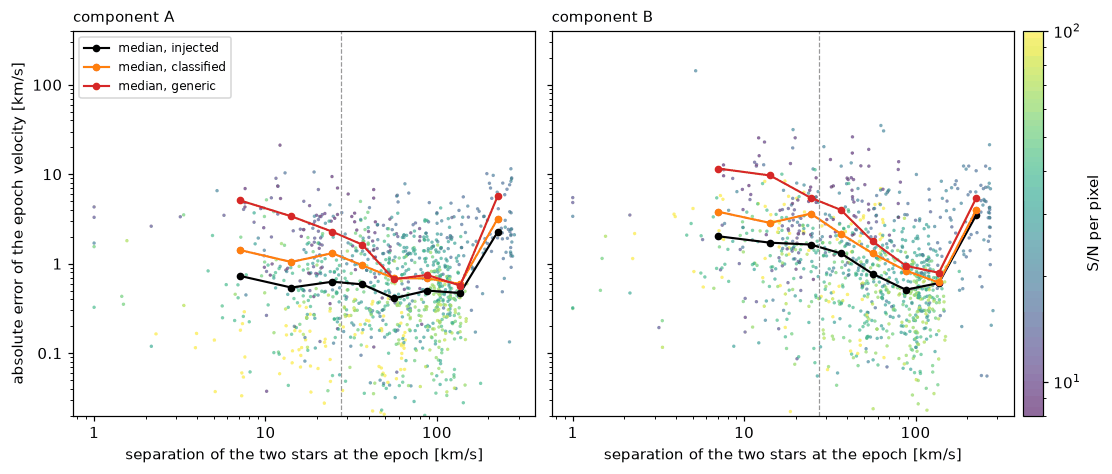

In [16]:
BINS = np.array([0.0, 10.0, 20.0, 30.0, 45.0, 70.0, 110.0, 170.0, 300.0])
centres = np.sqrt(np.maximum(BINS[:-1], 5.0) * BINS[1:])
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True)
for ax, component, name in zip(axes, (0, 1), ("A", "B"), strict=True):
    rows = results["injected"]
    separation = np.concatenate([row["separation"][row["good"]] for row in rows])
    snr = np.concatenate([row["snr"][row["good"]] for row in rows])
    points = ax.scatter(
        np.maximum(separation, 1.0),
        np.abs(pooled(rows, "error")[component]),
        c=snr,
        s=5,
        cmap="viridis",
        norm=matplotlib.colors.LogNorm(8.0, 100.0),
        alpha=0.6,
        linewidths=0,
    )
    for tier, colour in (("injected", "k"), ("classified", "C1"), ("generic", "C3")):
        rows = results[tier]
        separation = np.concatenate([row["separation"][row["good"]] for row in rows])
        error = np.abs(pooled(rows, "error")[component])
        which = np.digitize(separation, BINS) - 1
        median = [
            np.median(error[which == b]) if np.any(which == b) else np.nan
            for b in range(BINS.size - 1)
        ]
        ax.plot(centres, median, "o-", color=colour, ms=4, lw=1.4, label=f"median, {tier}")
    ax.axvline(2.3548 * delivered, color="0.6", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(0.02, 400.0)
    ax.set_xticks([1.0, 10.0, 100.0])
    ax.set_xticklabels(["1", "10", "100"])
    ax.set_yticks([0.1, 1.0, 10.0, 100.0])
    ax.set_yticklabels(["0.1", "1", "10", "100"])
    ax.set_xlabel("separation of the two stars at the epoch [km/s]")
    ax.set_title(f"component {name}", fontsize=10, loc="left")
axes[0].set_ylabel("absolute error of the epoch velocity [km/s]")
axes[0].legend(fontsize=8, loc="upper left")
fig.colorbar(points, ax=axes, label="S/N per pixel", pad=0.01)
fig.set_layout_engine("constrained")

The last figure shows the semi-amplitudes from the orbit fitted to each table. Each point
is one system: the larger of the two relative errors, against the largest separation of
the orbit. The dotted line is 5 percent, and an error above 400 percent is drawn at 400.

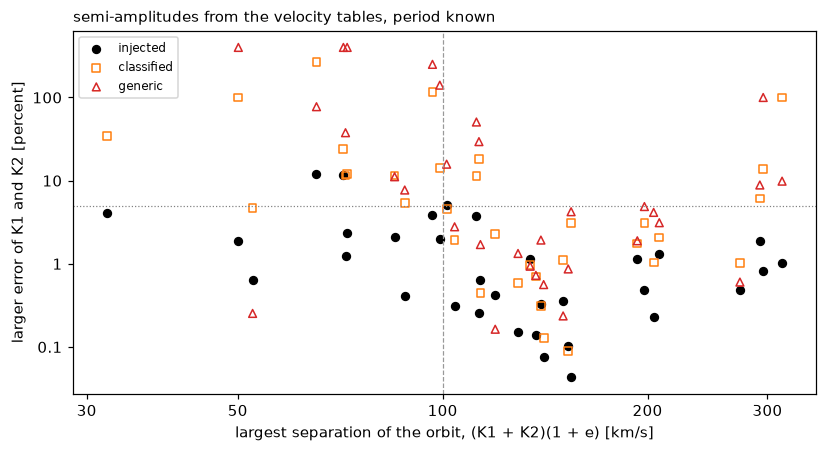

In [17]:
largest = np.array([system.max_separation_kms for system, _ in population])
fig, ax = plt.subplots(figsize=(7.4, 4.0))
for tier, marker, colour in (
    ("injected", "o", "k"),
    ("classified", "s", "C1"),
    ("generic", "^", "C3"),
):
    worst = np.array([np.max(np.abs(row["k_error"])) for row in results[tier]])
    ax.scatter(
        largest,
        np.clip(100 * worst, 0.02, 400.0),
        marker=marker,
        s=26,
        facecolors="none" if tier != "injected" else colour,
        edgecolors=colour,
        label=tier,
    )
ax.axhline(5.0, color="0.5", lw=0.8, ls=":")
ax.axvline(100.0, color="0.6", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks([30.0, 50.0, 100.0, 200.0, 300.0])
ax.set_xticklabels(["30", "50", "100", "200", "300"])
ax.set_yticks([0.1, 1.0, 10.0, 100.0])
ax.set_yticklabels(["0.1", "1", "10", "100"])
ax.minorticks_off()
ax.set_xlabel("largest separation of the orbit, (K1 + K2)(1 + e) [km/s]")
ax.set_ylabel("larger error of K1 and K2 [percent]")
ax.set_title("semi-amplitudes from the velocity tables, period known", fontsize=10, loc="left")
ax.legend(fontsize=8)
fig.set_layout_engine("constrained")

## Results

The numbers are those of the cells above.

- **Resolved epochs.** With templates at the labels of the stars, the velocity of an epoch
  whose lines are 60 km/s or more apart is measured at the photon limit: 0.65 and
  1.11 km/s rms at a S/N of 40 for stars with 62 and 38 percent of the light, in proportion
  to the inverse of the S/N. The quoted errors are calibrated once the noise correlation of
  the delivered grid is declared (pull rms 1.0 to 1.1, against 1.2 to 1.4 without it).
- **Blended epochs.** Between 10 km/s and about 1.5 times the FWHM of the line-spread
  function (27.5 km/s) the chi-square surface is a valley with two minima, and the noise
  makes the exchanged pair the lower at 46, 17 and 1 of 480 epochs at a S/N of 15, 40 and
  100. The curvature there is regular, so the quoted errors are those of a resolved epoch.
  The table flags an epoch as blended where a second minimum within 9 in chi-square gives
  a different pair of velocities: 33 of these 64 epochs, and 96 that were measured
  correctly. It records both minima there, and at each of the 33 the other one is the
  injected pair. The other 31 are the same pair in the other order to within three quoted
  errors, which an orbit assigns.
- **The orbit and the two minima.** With the period known, the orbit decides between the
  two minima of a flagged epoch. On the reference pair observed at 240 epochs it decides
  the 8 and 6 flagged epochs at a S/N of 15 and 40, and none of the 6 and 2 epochs that
  are wrong as measured remains wrong. The quoted errors of the decided epochs are
  smaller than their errors, with a pull rms of 0.7 to 1.9.
- **The 33 systems with templates at the injected labels.** 93 percent of the epochs are
  usable as measured, and a second minimum flags 3 percent. The orbit decides 34 of those
  epochs, one of them wrongly, and 97 percent are usable afterwards. The median error of
  an epoch velocity is 0.55 km/s for the primaries and 0.98 km/s for the secondaries, and
  99.4 and 98.9 percent of the velocities are within three quoted errors. The orbit fitted
  to a table gives both semi-amplitudes within 5 percent for 21 of the 22 systems with a
  largest separation above 100 km/s, at median errors of 0.22 and 0.26 percent, and for 9
  of the 11 below. The three exceptions have periods of 45 to 844 d, eccentricities of 0.5
  to 0.6 and a S/N of 9 to 17. With the light fractions measured and not declared the
  counts are 21 and 8, and the fraction is measured to 0.003.
- **Imperfect templates.** With the label errors of a classification the median errors are
  0.87 and 1.57 km/s, 90 and 86 percent of the velocities are within three quoted errors,
  and both semi-amplitudes are within 5 percent for 17 of 22 systems above 100 km/s and
  for 1 of 11 below. With one free scale per epoch the errors are 0.77 and 1.33 km/s, and
  the counts 19 of 22 and 3 of 11. With the generic templates the errors are 1.24 and
  2.32 km/s, 31 and 34 percent of the velocities are more than three quoted errors off, a
  second minimum flags 12 percent of the epochs, and 16 of 22 and 1 of 11 systems are
  within 5 percent. The quoted errors do not include the mismatch of the templates.
- **The decided epochs under imperfect templates.** The decided epochs share that
  mismatch. Of the 63 decided under `classified`, 20 are wrong afterwards, and of the 126
  under `generic`, 55, where 5 and 25 percent of the other usable epochs are wrong by the
  same criterion. Of those wrong epochs, 11 and 40 belong to one and to two systems whose
  companion the templates do not measure. With the flagged epochs left out, the numbers
  of systems within 5 percent are 17 and 2 under `classified`, 18 and 3 with the free
  scale and 16 and 1 under `generic`: the decisions move one system each way.
- **Templates that measure no light.** Two systems under `classified` and one under
  `generic` have no epoch at which both templates receive a positive amplitude: a 7 percent
  secondary, a template twice as broad as its star, and a pair of 6950 and 6530 K that is
  never resolved, against templates of 6000 and 5000 K. `todcor` then raises an error and
  holds no light fraction. Measured here with the amplitudes of each epoch, none of them
  has both semi-amplitudes within 5 percent.
- **Assignment.** With the injected templates 7 percent of the epochs are measured with
  the two stars exchanged, and the orbit re-assigns them. One exchange by the first fit
  gives both semi-amplitudes within 5 percent for 18 of the 22 systems above 100 km/s
  under the first two tiers and for 12 to 14 under the other three, where
  `assign_components` gives 21 and 16 to 19. A template pair is matched to the two stars
  in the other order as a whole for 6 to 9 of the 33 systems once the labels are in error,
  which the comparison allows for and a user cannot detect from the table.
- **Systemic velocity.** Library templates are at rest, so the velocities are absolute.
  The median error of the systemic velocity is 0.09 km/s with the injected templates and
  0.28 km/s with the generic ones.
- **Cost.** A correlation takes 12 ms per epoch with the light fractions held and 35 to
  43 ms with them measured, on spectra of 961 samples. The 33 systems take under a minute
  per tier, the orbit fits included.

### Comparison with the disentangling

The recorded third run of the [disentangling benchmark](gaia-rvs-benchmark.ipynb) analysed
the same epochs, and measured its epoch velocities by the same correlation against the
disentangled components. Its `oracle` tier is given the orbit and the light ratio, and its
`orbit` tier the period. Every tier of this notebook is given the period, for the orbit
fit and the assignment. The table gives the number of systems with both semi-amplitudes
within 5 percent, on either side of a largest separation of 100 km/s, and the median error
of an epoch velocity of the primary and the secondary on the 14 Gaia orbits and on the 19
field systems. The third run predates the blend flag and the search of this notebook.

| analysis | above 100 km/s | below | Gaia orbits [km/s] | field [km/s] |
|---|---|---|---|---|
| disentangling, `oracle` | 21 of 22 | 1 of 11 | 0.64, 0.79 | 0.91, 1.21 |
| disentangling, `orbit` | 19 of 22 | 2 of 11 | 0.59, 0.83 | 0.95, 1.33 |
| TODCOR, `injected` | 21 of 22 | 9 of 11 | 0.42, 0.61 | 0.62, 1.07 |
| TODCOR, `classified, free scale` | 19 of 22 | 3 of 11 | 0.62, 0.87 | 0.80, 1.46 |
| TODCOR, `generic` | 16 of 22 | 1 of 11 | 0.98, 1.64 | 1.32, 2.49 |

- **Where the labels of the stars are known**, the correlation against library templates
  has epoch errors 12 to 34 percent below those against the disentangled components. It
  recovers the semi-amplitudes of 9 of the 11 systems whose lines never separate by
  100 km/s, where the disentangling recovers 1 or 2, and it takes one to two seconds per
  system where the disentangling takes 7 to 15 minutes.
- **Where they are not**, the order is reversed. With the period alone the disentangling
  recovers 19 of 22 systems above 100 km/s and 2 of 11 below, and the generic templates 16
  and 1. The disentangling uses no template, so its result does not depend on a
  classification.
- **Faint secondaries.** For the secondary with 5 percent of the light, the semi-amplitude
  from the table is 4 percent off with the injected templates and 51 percent off with the
  generic ones. The disentangling recovered it within 0.5 percent under every tier.

## Limitations

The simulation is that of the disentangling benchmark and has its limitations: the
line-spread function is a Gaussian, and the epochs follow the statistics of the scanning
law and not its phase. Four further limitations apply here.

- The `injected` and `labels` tiers use the spectra from which the epochs were made, so
  they have no template mismatch. The `classified` tier has label errors, but its templates
  and the simulated stars are spectra of the same grid. A real star differs from every
  model of a grid, by an amount this simulation does not contain.
- The period is declared wherever an orbit is fitted and wherever the epochs of a pair are
  assigned to its stars. A table measured without a period needs the period search of the
  pipeline, whose recovery rate the disentangling benchmark measures.
- The label errors of the `classified` tier are one draw per system from the stated
  widths. The errors of a classification of a composite spectrum can be larger.
- An epoch flagged for a second minimum is decided by an orbit, which needs the period.
  Without one it is left out. An epoch flagged by the curvature of the surface has one
  elongated minimum and is not decided. The quoted errors of a decided epoch are those of
  the curvature at one minimum of a blended surface, and are smaller than its errors.

References: Bohlin, R. C., et al. 2017, AJ, 153, 234; Cropper, M., et al. 2018, A&A, 616,
A5; Mészáros, Sz., et al. 2024, PASP, 136, 4504; Moe, M. & Di Stefano, R. 2017, ApJS, 230,
15; Zucker, S. 2003, MNRAS, 342, 1291; Zucker, S. & Mazeh, T. 1994, ApJ, 420, 806.